# Taller 07 · Clasificación de dígitos con KNN y RNN
**Inteligencia Artificial · ELP 8012 · Universidad del Norte**  
**Profesor:** Eduardo Zurek, Ph.D.  
**Grupo 15 — Integrantes:** Galvis Pajaro, Carlos · Molina Vega, Dayana · Romero Pemberthy, Juan

## Objetivo y alcance
Clasificar imágenes de dígitos del 0 al 9 con `load_digits` de scikit-learn. Se comparan **K vecinos más cercanos (KNN)** y **vecinos dentro de un radio (RNN)**. Aquí RNN significa *Radius Nearest Neighbors*, no una red neuronal recurrente.

El encabezado del PDF dice «Reducción de Dimensiones», pero sus temas y seis requisitos piden clasificadores KNN/RNN. Esta solución desarrolla esos requisitos con los **64 píxeles originales**; no incorpora PCA ni cambia el problema solicitado.

**Cómo usarlo en Colab:** subir este archivo `.ipynb` y seleccionar **Entorno de ejecución → Ejecutar todas**. Basta una CPU; no requiere GPU, Google Drive ni archivos de datos externos. Las salidas guardadas permiten leer la solución sin ejecutarla. Los resultados se recalculan al ejecutar todas las celdas.

| Requisito del PDF | Dónde se resuelve |
|---|---|
| Dataset `digits` de sklearn | Sección 2 |
| 80 % entrenamiento y 20 % prueba | Sección 3 |
| K-fold = 4 durante entrenamiento | Sección 4 |
| Rango de K y figura de métricas | Sección 6 |
| Seleccionar el mejor K | Sección 6 |
| Rango de R y figura de métricas | Sección 7 |
| Seleccionar el mejor R | Sección 7 |
| Código y explicación en Markdown | Todas las secciones |

La comparación final usa el 20 % reservado, **después** de fijar K, R y el criterio de selección. «Mejor» significa mejor dentro de las rejillas y particiones de este experimento.

## 1. Fundamento y decisiones del experimento
Una imagen de 8 × 8 se convierte en un vector de 64 intensidades. La distancia euclidiana entre dos imágenes normalizadas es:

$$d(\mathbf{x},\mathbf{z})=\sqrt{\sum_{j=1}^{64}(x_j-z_j)^2}.$$

- **KNN:** busca exactamente K imágenes de entrenamiento cercanas y combina sus votos. Con K pequeño la decisión es muy local; con K grande pueden incorporarse otras clases.
- **RNN:** usa todas las imágenes a distancia menor o igual que R. El número de vecinos varía según la imagen; un radio pequeño puede no encontrar ninguno y uno grande puede mezclar clases.
- **Votos:** ambos modelos usan `weights='distance'`: los vecinos cercanos pesan más, aproximadamente $w_i=1/d_i$. Scikit-learn maneja los vecinos a distancia cero sin dividir por cero. En empate de votos toma la primera clase del orden interno.
- **Escala:** cada píxel ya usa la misma unidad y el rango documentado 0–16. Se divide por **16 fijo** para obtener 0–1. Esta transformación no aprende estadísticas del conjunto y no filtra información de prueba. Se incluye en un `Pipeline` para aplicarla de igual forma en validación y predicción. Todas las distancias se dividen por 16: R=2 equivale a radio 32 en intensidades originales.
- **Semilla:** 42. Se mantiene fija la división y se comparten los mismos folds entre modelos.

### Métricas y selección
Para cada dígito $c$, se calcula precisión $P_c=TP_c/(TP_c+FP_c)$, recall $R_c=TP_c/(TP_c+FN_c)$ y $F1_c=2P_cR_c/(P_c+R_c)$. Si el denominador es cero, se asigna cero (`zero_division=0`). **Macro** significa el promedio simple de las 10 clases; F1 macro promedia los F1 individuales, no se obtiene a partir de los promedios de precisión y recall.

| Métrica | Interpretación |
|---|---|
| Exactitud (*accuracy*) | Fracción de imágenes correctamente clasificadas |
| Precisión macro | Promedio, por dígito, de cuánto acertamos cuando lo predecimos |
| Recall macro | Promedio, por dígito, de cuántos ejemplos reales recuperamos |
| F1 macro | Equilibrio entre precisión y recall, dando igual importancia a cada clase |

**Regla fijada antes de evaluar:** maximizar F1 macro medio en los 4 folds; en empate numérico a 12 decimales, priorizar exactitud media y luego el menor K o R. No se exige que un candidato maximice todas las métricas a la vez. Precisión y recall se muestran como diagnóstico. No se crean ponderaciones arbitrarias adicionales.

### 1.1. Librerías y parámetros
Colab normalmente incluye estas librerías. Si un entorno local no las tiene, instalar `numpy pandas matplotlib scikit-learn threadpoolctl`. La celda muestra las versiones utilizadas; las salidas de esta entrega se generaron con scikit-learn 1.8.0. Otras versiones pueden introducir diferencias pequeñas en empates numéricos.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from threadpoolctl import threadpool_limits

SEMILLA = 42
VALORES_K = list(range(1, 41))
VALORES_R = np.round(np.arange(0.5, 4.01, 0.1), 2).tolist()
CLASES = np.arange(10)
NOMBRES_METRICAS = {
    'accuracy': 'Exactitud', 'precision_macro': 'Precisión macro',
    'recall_macro': 'Recall macro', 'f1_macro': 'F1 macro'
}
COLORES = ['#205C90', '#B46918', '#657B35', '#9B4F79']
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': False, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)
pd.set_option('display.precision', 5)
print(f'Python {sys.version.split()[0]} | sklearn {sklearn.__version__} | '
      f'NumPy {np.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}')
print(f'K: {VALORES_K[0]} a {VALORES_K[-1]} (paso 1); '
      f'R: {VALORES_R[0]} a {VALORES_R[-1]} (paso 0.1, escala 0–1).')

Python 3.12.14 | sklearn 1.8.0 | NumPy 2.3.5 | pandas 2.2.3 | matplotlib 3.10.8
K: 1 a 40 (paso 1); R: 0.5 a 4.0 (paso 0.1, escala 0–1).


## 2. Cargar y comprobar el dataset
`digits` está incluido en scikit-learn: contiene 1.797 imágenes de 8 × 8, 64 variables y 10 etiquetas. No es MNIST. Revisamos dimensiones, valores ausentes y rango de intensidades. Conservamos todos los ejemplos.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float64)
y = digits.target.astype(int)
assert X.shape == (1797, 64)
assert np.isfinite(X).all()
assert X.min() >= 0 and X.max() <= 16
assert np.array_equal(np.unique(y), CLASES)
print('Matriz X:', X.shape, '| Etiquetas y:', y.shape)
print('Intensidad mínima y máxima:', X.min(), X.max())
print('Filas de píxeles duplicadas:', len(X) - len(np.unique(X, axis=0)))

Matriz X: (1797, 64) | Etiquetas y: (1797,)
Intensidad mínima y máxima: 0.0 16.0
Filas de píxeles duplicadas: 0


## 3. Separación estratificada 80/20
La estratificación conserva aproximadamente las proporciones de los diez dígitos. `test_size=0.20` produce **1.437 imágenes de entrenamiento y 360 de prueba**: el pequeño ajuste frente a 80/20 exacto se debe a que el número de imágenes es entero.

Separar los índices permite comprobar que ninguna imagen está simultáneamente en ambos conjuntos. Desde aquí, las búsquedas de parámetros solo reciben `X_train` y `y_train`. Mostrar el tamaño y los conteos de clases no implica ajustar el modelo con la prueba.

In [3]:
indices_train, indices_test = train_test_split(
    np.arange(len(y)), test_size=0.20, random_state=SEMILLA, stratify=y)
X_train, X_test = X[indices_train], X[indices_test]
y_train, y_test = y[indices_train], y[indices_test]
assert set(indices_train).isdisjoint(indices_test)
assert len(indices_train) + len(indices_test) == len(y)
assert len(y_train) == 1437 and len(y_test) == 360
print(f'Entrenamiento: {len(y_train)} ({len(y_train)/len(y):.2%})')
print(f'Prueba: {len(y_test)} ({len(y_test)/len(y):.2%})')
distribucion = pd.DataFrame({
    'Dígito': CLASES, 'Entrenamiento': np.bincount(y_train, minlength=10),
    'Prueba': np.bincount(y_test, minlength=10)})
display(distribucion)

Entrenamiento: 1437 (79.97%)
Prueba: 360 (20.03%)


,Dígito,Entrenamiento,Prueba
0,0,142,36
1,1,146,36
2,2,142,35
3,3,146,37
4,4,145,36
5,5,145,37
6,6,145,36
7,7,143,36
8,8,139,35
9,9,144,36


### 3.1. Ejemplos del conjunto de entrenamiento
Se muestra una imagen de cada clase. La forma de escribir un mismo número puede variar: esa variabilidad es lo que los vecinos intentan reconocer.

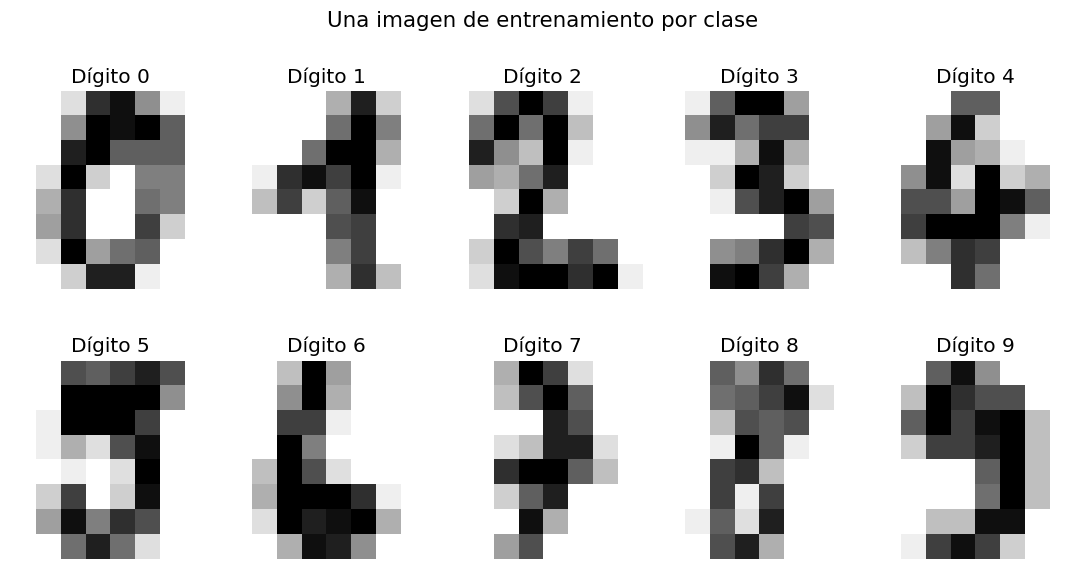

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5.6))
for digito, ax in zip(CLASES, axes.ravel()):
    posicion = np.flatnonzero(y_train == digito)[0]
    ax.imshow(X_train[posicion].reshape(8, 8), cmap='gray_r', vmin=0, vmax=16)
    ax.set_title(f'Dígito {digito}')
    ax.axis('off')
fig.suptitle('Una imagen de entrenamiento por clase', fontsize=14)
fig.tight_layout(h_pad=2.5)
plt.show()

## 4. Validación cruzada con 4 folds
Se usa `StratifiedKFold(n_splits=4)`, una variante de K-fold que conserva aproximadamente la distribución de clases en cada partición.

Para **cada candidato** se realizan cuatro rondas: ajustar con tres folds y validar con el restante. Cada imagen de entrenamiento valida exactamente una vez. El promedio de las cuatro métricas de validación determina la selección. La prueba del 20 % no participa en estas rondas. Después, `refit` reajusta automáticamente el candidato elegido con las 1.437 imágenes de entrenamiento.

**No confundir:** K es el número de vecinos de KNN; el 4 de K-fold es el número de particiones de validación. En estos clasificadores `fit` conserva ejemplos y prepara la búsqueda de vecinos, aunque no entrena pesos como una red neuronal.

In [5]:
partidor = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEMILLA)
folds = list(partidor.split(X_train, y_train))
conteo_validaciones = np.zeros(len(y_train), dtype=int)
filas_folds = []
for numero, (idx_ajuste, idx_validacion) in enumerate(folds, start=1):
    assert set(idx_ajuste).isdisjoint(idx_validacion)
    assert len(np.unique(y_train[idx_ajuste])) == 10
    assert len(np.unique(y_train[idx_validacion])) == 10
    conteo_validaciones[idx_validacion] += 1
    filas_folds.append({'Fold': numero, 'Para ajustar': len(idx_ajuste),
                        'Para validar': len(idx_validacion)})
assert np.all(conteo_validaciones == 1)
assert max(VALORES_K) <= min(len(a) for a, _ in folds)
display(pd.DataFrame(filas_folds))

,Fold,Para ajustar,Para validar
0,1,1077,360
1,2,1078,359
2,3,1078,359
3,4,1078,359


## 5. Funciones comunes y tratamiento de RNN sin vecinos
En RNN se configura `outlier_label='most_frequent'`: si una imagen no tiene vecinos dentro del radio, se le asigna la clase más frecuente del **subconjunto utilizado para ajustar ese fold**. Así no se pierde ninguna observación al calcular las métricas. Es una decisión de respaldo, no una predicción sustentada en vecinos; por eso también se mide la **cobertura**, fracción de imágenes con al menos un vecino.

Un radio con buena exactitud no se debe interpretar sin revisar su cobertura. Además se muestra el número medio de vecinos. La política de respaldo se fija antes de la búsqueda y también se aplica en prueba. No usamos etiquetas de prueba para definirla.

In [6]:
def normalizar_pixeles(datos):
    # Escala fija documentada; no calcula máximos ni medias sobre los datos.
    return np.asarray(datos, dtype=np.float64) / 16.0


def crear_pipeline(clasificador):
    return Pipeline([('escala', FunctionTransformer(normalizar_pixeles)),
                     ('modelo', clasificador)])


def metricas_clasificacion(reales, predichas):
    return {
        'accuracy': accuracy_score(reales, predichas),
        'precision_macro': precision_score(reales, predichas, labels=CLASES,
                                           average='macro', zero_division=0),
        'recall_macro': recall_score(reales, predichas, labels=CLASES,
                                     average='macro', zero_division=0),
        'f1_macro': f1_score(reales, predichas, labels=CLASES,
                            average='macro', zero_division=0),
    }


def evaluar_cv(pipeline, datos, etiquetas):
    prediccion = pipeline.predict(datos)
    resultado = metricas_clasificacion(etiquetas, prediccion)
    modelo = pipeline.named_steps['modelo']
    if isinstance(modelo, RadiusNeighborsClassifier):
        normalizados = pipeline.named_steps['escala'].transform(datos)
        vecinos = modelo.radius_neighbors(normalizados, return_distance=False)
        cantidades = np.array([len(v) for v in vecinos])
        resultado['cobertura'] = np.mean(cantidades > 0)
        resultado['vecinos_medios'] = np.mean(cantidades)
    return resultado


def indice_mejor(resultado_cv):
    # Los candidatos están ordenados de menor a mayor K o R.
    return min(range(len(resultado_cv['params'])), key=lambda i: (
        -round(float(resultado_cv['mean_test_f1_macro'][i]), 12),
        -round(float(resultado_cv['mean_test_accuracy'][i]), 12), i))


def tabla_cv(busqueda, parametro, etiqueta):
    resultados = busqueda.cv_results_
    tabla = pd.DataFrame({etiqueta: [p[parametro] for p in resultados['params']]})
    metricas = list(NOMBRES_METRICAS)
    if 'mean_test_cobertura' in resultados:
        metricas += ['cobertura', 'vecinos_medios']
    for metrica in metricas:
        tabla[metrica] = resultados[f'mean_test_{metrica}']
        tabla[f'{metrica}_std'] = resultados[f'std_test_{metrica}']
    tabla['seleccionado'] = np.arange(len(tabla)) == busqueda.best_index_
    assert np.isfinite(tabla.select_dtypes(include='number').to_numpy()).all()
    return tabla

### 5.1. Figura reutilizable para las métricas
Cada panel muestra la media de validación y una banda de **±1 desviación estándar entre los 4 folds**; no es un intervalo de confianza. Las bandas se limitan a 0–1 para mostrarlas. La línea vertical marca el candidato seleccionado. Los ejes verticales usan 0–1 para que las gráficas de K y R tengan una escala comparable; las tablas permiten distinguir diferencias pequeñas.

In [7]:
def graficar_metricas(tabla, parametro, mejor, nombre):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True, sharey=True)
    x = tabla[parametro].to_numpy()
    for ax, (metrica, titulo), color in zip(axes.ravel(), NOMBRES_METRICAS.items(), COLORES):
        media = tabla[metrica].to_numpy()
        desviacion = tabla[f'{metrica}_std'].to_numpy()
        ax.plot(x, media, 'o-', color=color, markersize=3, linewidth=1.6)
        ax.fill_between(x, np.clip(media-desviacion, 0, 1),
                        np.clip(media+desviacion, 0, 1), color=color, alpha=0.15)
        ax.axvline(mejor, color='#323A42', linestyle='--', linewidth=1.2,
                   label=f'Elegido: {parametro}={mejor:g}')
        ax.set(title=titulo, xlabel=parametro, ylabel='Puntuación de validación', ylim=(0, 1.02))
        ax.tick_params(labelbottom=True, labelleft=True)
        ax.grid(alpha=0.2)
        ax.legend(loc='lower right', fontsize=9)
    fig.suptitle(f'{nombre}: desempeño en validación cruzada de 4 folds', fontsize=15)
    fig.tight_layout()
    plt.show()


def explicar_ganador(tabla, parametro, ganador, nombre):
    fila = tabla.loc[tabla['seleccionado']].iloc[0]
    display(Markdown(
        f'**{nombre} seleccionado: {parametro} = {ganador:g}.** '
        f'F1 macro de validación = **{fila["f1_macro"]:.5f}** '
        f'(desviación entre folds: {fila["f1_macro_std"]:.5f}); '
        f'exactitud = **{fila["accuracy"]:.5f}**, '
        f'precisión macro = {fila["precision_macro"]:.5f} y '
        f'recall macro = {fila["recall_macro"]:.5f}. '
        'La elección se obtiene de validación, no de prueba.'))
    if ganador in (tabla[parametro].min(), tabla[parametro].max()):
        print('El ganador está en un extremo de la rejilla; no demuestra un óptimo fuera del rango evaluado.')

## 6. KNN: rango de K, búsqueda y selección
Se evalúan **40 valores: K=1,2,…,40**, desde decisiones muy locales hasta vecindarios más amplios. Cada valor realiza 4 ajustes: **160 ajustes de validación**, más el reajuste final. Se mantienen fijos distancia euclidiana y votos por distancia para estudiar el efecto de K.

`GridSearchCV` aplica la misma evaluación a cada candidato. `refit=indice_mejor` usa la regla F1 → exactitud → menor parámetro y devuelve el modelo ya reajustado. Con `refit` callable se lee la puntuación desde `cv_results_` y `best_index_`, sin asumir que exista `best_score_`.

In [8]:
pipeline_knn = crear_pipeline(KNeighborsClassifier(
    weights='distance', metric='euclidean', algorithm='brute', n_jobs=1))
busqueda_knn = GridSearchCV(
    pipeline_knn, {'modelo__n_neighbors': VALORES_K}, scoring=evaluar_cv,
    cv=folds, refit=indice_mejor, n_jobs=1, error_score='raise', return_train_score=False)
# Evita crear demasiados hilos para un dataset pequeño.
with threadpool_limits(limits=1):
    busqueda_knn.fit(X_train, y_train)
mejor_k = busqueda_knn.best_params_['modelo__n_neighbors']
modelo_knn = busqueda_knn.best_estimator_
tabla_knn = tabla_cv(busqueda_knn, 'modelo__n_neighbors', 'K')
columnas_knn = ['K', *NOMBRES_METRICAS, 'f1_macro_std', 'seleccionado']
display(tabla_knn[columnas_knn].sort_values(
    ['f1_macro', 'accuracy', 'K'], ascending=[False, False, True]).head(10))
explicar_ganador(tabla_knn, 'K', mejor_k, 'KNN')

El ganador está en un extremo de la rejilla; no demuestra un óptimo fuera del rango evaluado.


,K,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_std,seleccionado
0,1,0.98956,0.98993,0.98954,0.98953,0.00359,True
1,2,0.98956,0.98993,0.98954,0.98953,0.00359,False
2,3,0.98678,0.98732,0.98674,0.98677,0.00496,False
3,4,0.98469,0.98512,0.98466,0.98464,0.00413,False
5,6,0.98399,0.98451,0.98389,0.98393,0.00360,False
7,8,0.98260,0.98319,0.98246,0.98252,0.00454,False
4,5,0.98260,0.98309,0.98246,0.98251,0.00449,False
6,7,0.98260,0.98321,0.98244,0.98250,0.00302,False
9,10,0.98121,0.98181,0.98103,0.98107,0.00234,False
8,9,0.98051,0.98104,0.98031,0.98036,0.00196,False


**KNN seleccionado: K = 1.** F1 macro de validación = **0.98953** (desviación entre folds: 0.00359); exactitud = **0.98956**, precisión macro = 0.98993 y recall macro = 0.98954. La elección se obtiene de validación, no de prueba.

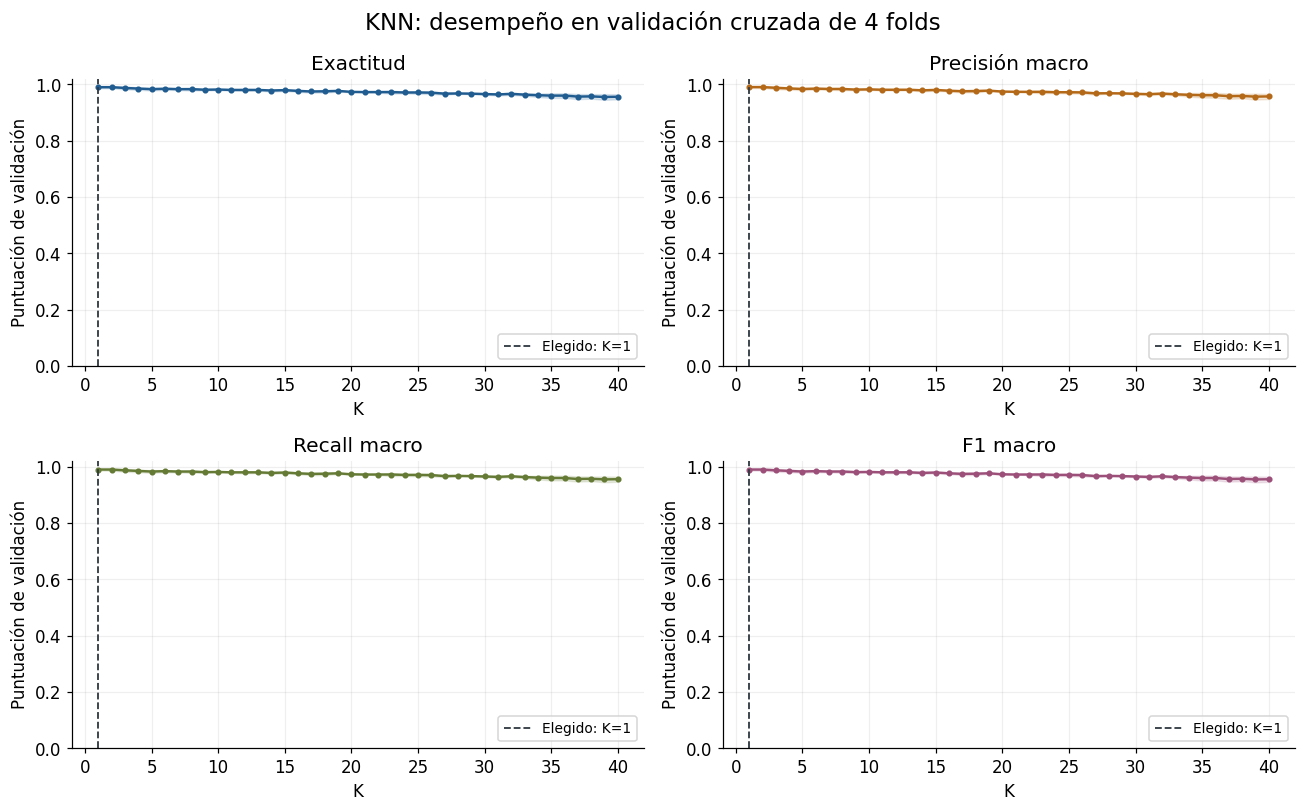

In [9]:
graficar_metricas(tabla_knn, 'K', mejor_k, 'KNN')

**Lectura de KNN:** comparar el valor seleccionado con sus candidatos cercanos y la variabilidad entre folds. La banda muestra cuánto cambia el desempeño según las imágenes de validación. Una pequeña diferencia entre medias no demuestra una superioridad estadísticamente significativa. La elección es reproducible bajo el criterio fijado; no garantiza que ese K sea el mejor con otra semilla o población.

## 7. RNN: rango de R, búsqueda y selección
Se evalúan **36 radios desde 0,5 hasta 4,0 en pasos de 0,1**, medidos después de dividir píxeles por 16. Es una rejilla fija que cubre vecindarios pequeños y amplios dentro de la distancia teórica máxima 8 entre vectores de 64 componentes en 0–1. No se eligió mirando la prueba. Son **144 ajustes de validación**, más el reajuste final.

El respaldo por clase más frecuente permite evaluar también los radios pequeños sin eliminar imágenes ni interrumpir la búsqueda. F1 y las demás métricas incluyen **todas** las predicciones, incluidas las que utilizan ese respaldo.

In [10]:
pipeline_rnn = crear_pipeline(RadiusNeighborsClassifier(
    weights='distance', metric='euclidean', algorithm='brute', n_jobs=1,
    outlier_label='most_frequent'))
busqueda_rnn = GridSearchCV(
    pipeline_rnn, {'modelo__radius': VALORES_R}, scoring=evaluar_cv,
    cv=folds, refit=indice_mejor, n_jobs=1, error_score='raise', return_train_score=False)
with threadpool_limits(limits=1):
    busqueda_rnn.fit(X_train, y_train)
mejor_r = busqueda_rnn.best_params_['modelo__radius']
modelo_rnn = busqueda_rnn.best_estimator_
tabla_rnn = tabla_cv(busqueda_rnn, 'modelo__radius', 'R')
columnas_rnn = ['R', *NOMBRES_METRICAS, 'f1_macro_std', 'cobertura', 'vecinos_medios', 'seleccionado']
display(tabla_rnn[columnas_rnn].sort_values(
    ['f1_macro', 'accuracy', 'R'], ascending=[False, False, True]).head(10))
explicar_ganador(tabla_rnn, 'R', mejor_r, 'RNN')
fila_rnn = tabla_rnn.loc[tabla_rnn['seleccionado']].iloc[0]
print(f'Cobertura media del radio seleccionado: {fila_rnn["cobertura"]:.2%}')
print(f'Número medio de vecinos en validación: {fila_rnn["vecinos_medios"]:.2f}')

Cobertura media del radio seleccionado: 99.65%
Número medio de vecinos en validación: 35.31


,R,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_std,cobertura,vecinos_medios,seleccionado
14,1.9,0.98121,0.98232,0.98103,0.98120,0.00451,0.99652,35.31055,True
13,1.8,0.97843,0.98027,0.97815,0.97842,0.00306,0.99304,27.93118,False
12,1.7,0.97356,0.97614,0.97329,0.97374,0.00442,0.98678,21.59283,False
15,2.0,0.97286,0.97427,0.97255,0.97271,0.00239,0.99652,44.49640,False
16,2.1,0.96730,0.96857,0.96705,0.96708,0.00892,0.99930,55.70440,False
11,1.6,0.96451,0.97110,0.96420,0.96560,0.00444,0.97425,16.18826,False
17,2.2,0.95616,0.95739,0.95586,0.95572,0.00701,0.99930,70.30836,False
18,2.3,0.94504,0.94636,0.94476,0.94453,0.01073,1.00000,89.30601,False
10,1.5,0.93459,0.95752,0.93399,0.93875,0.00446,0.94224,11.84159,False
19,2.4,0.93460,0.93603,0.93432,0.93404,0.00992,1.00000,114.42742,False


**RNN seleccionado: R = 1.9.** F1 macro de validación = **0.98120** (desviación entre folds: 0.00451); exactitud = **0.98121**, precisión macro = 0.98232 y recall macro = 0.98103. La elección se obtiene de validación, no de prueba.

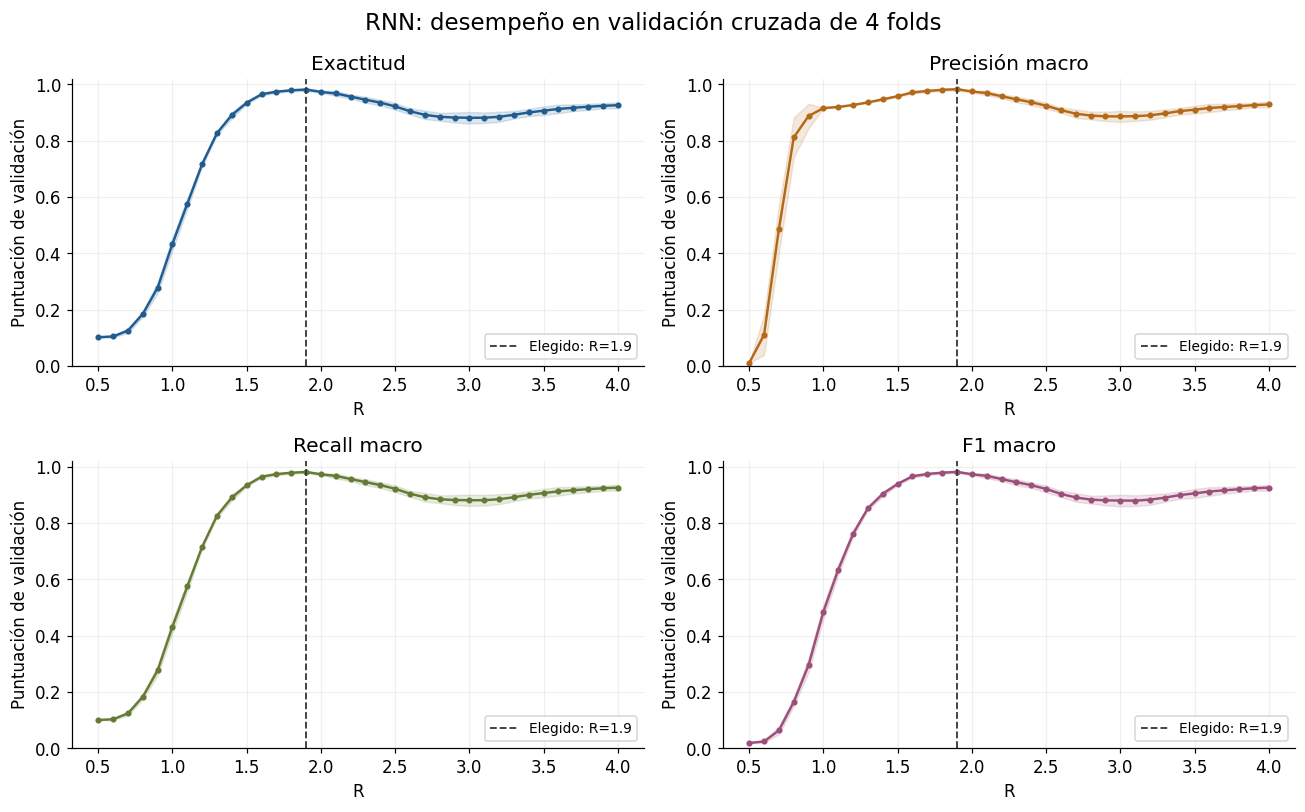

In [11]:
graficar_metricas(tabla_rnn, 'R', mejor_r, 'RNN')

### 7.1. Cobertura y cantidad de vecinos según el radio
La cobertura mide disponibilidad de vecinos, no aciertos. Al aumentar R, la cobertura no disminuye, pero la calidad de clasificación puede disminuir por mezclar dígitos distintos. La cantidad media de vecinos incluye ceros. Ambos valores se promedian primero dentro de cada fold y luego entre los cuatro folds.

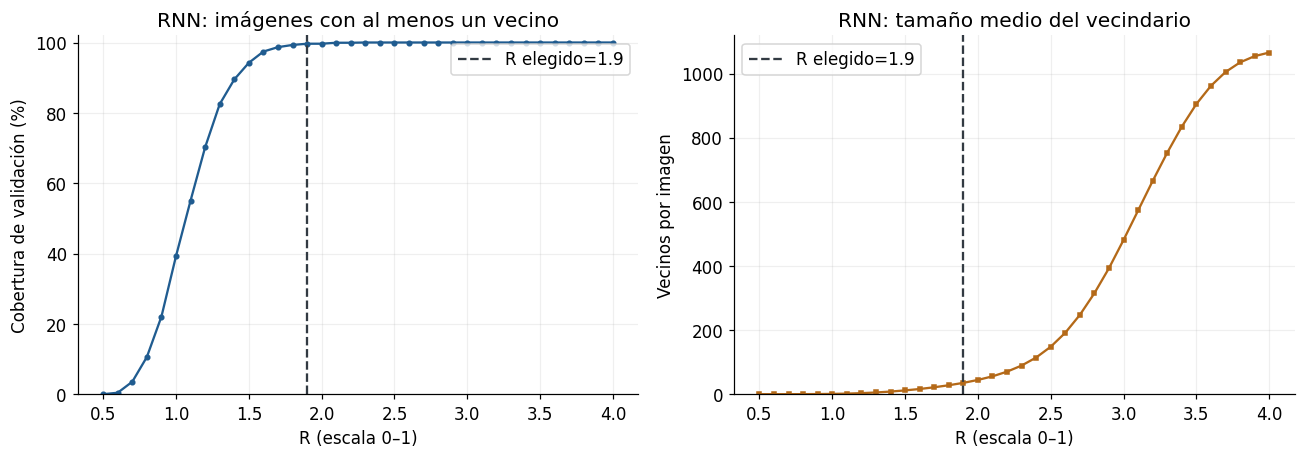

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(tabla_rnn['R'], tabla_rnn['cobertura']*100, 'o-', color=COLORES[0], markersize=3)
axes[0].set(title='RNN: imágenes con al menos un vecino', xlabel='R (escala 0–1)',
            ylabel='Cobertura de validación (%)', ylim=(0, 102))
axes[1].plot(tabla_rnn['R'], tabla_rnn['vecinos_medios'], 's-', color=COLORES[1], markersize=3)
axes[1].set(title='RNN: tamaño medio del vecindario', xlabel='R (escala 0–1)',
            ylabel='Vecinos por imagen')
axes[1].set_ylim(bottom=0)
for ax in axes:
    ax.axvline(mejor_r, color='#323A42', linestyle='--', label=f'R elegido={mejor_r:g}')
    ax.grid(alpha=0.2)
    ax.legend()
fig.tight_layout()
plt.show()
assert np.all(np.diff(tabla_rnn['cobertura']) >= -1e-12)

## 8. Congelar la selección antes de abrir la prueba
Los valores de K y R ya están fijados. Si fuera necesario recomendar una familia antes de conocer prueba, se tomaría la de mayor F1 macro medio en validación; en empate a 12 decimales, exactitud y luego KNN como regla fija. La prueba servirá para informar el desempeño de ambas familias y de esa recomendación previa, no para volver a ajustar parámetros.

In [13]:
seleccion_cv = pd.DataFrame([
    {'Modelo': 'KNN', 'Parámetro': f'K={mejor_k}',
     **{m: float(tabla_knn.loc[tabla_knn['seleccionado'], m].iloc[0]) for m in NOMBRES_METRICAS}},
    {'Modelo': 'RNN', 'Parámetro': f'R={mejor_r:g}',
     **{m: float(tabla_rnn.loc[tabla_rnn['seleccionado'], m].iloc[0]) for m in NOMBRES_METRICAS}}
]).set_index('Modelo')
modelo_preferido_cv = min(['KNN', 'RNN'], key=lambda nombre: (
    -round(seleccion_cv.loc[nombre, 'f1_macro'], 12),
    -round(seleccion_cv.loc[nombre, 'accuracy'], 12), nombre != 'KNN'))
display(seleccion_cv)
print('Familia preferida por validación, antes de evaluar prueba:', modelo_preferido_cv)

Familia preferida por validación, antes de evaluar prueba: KNN


,Parámetro,accuracy,precision_macro,recall_macro,f1_macro
Modelo,,,,,
KNN,K=1,0.98956,0.98993,0.98954,0.98953
RNN,R=1.9,0.98121,0.98232,0.98103,0.98120


## 9. Evaluación final en las 360 imágenes de prueba
Se predice una vez con cada modelo final y se reutilizan esas predicciones para tablas y figuras. Las puntuaciones de prueba son una evaluación separada. La métrica de validación del ganador puede tener cierto optimismo por la selección entre muchos candidatos; no debe confundirse con esta evaluación final.

In [14]:
modelos = {'KNN': modelo_knn, 'RNN': modelo_rnn}
with threadpool_limits(limits=1):
    predicciones = {nombre: modelo.predict(X_test) for nombre, modelo in modelos.items()}
resultado_prueba = pd.DataFrame({
    nombre: metricas_clasificacion(y_test, pred) for nombre, pred in predicciones.items()
}).T
resultado_prueba['Aciertos'] = [int(np.sum(predicciones[n] == y_test)) for n in resultado_prueba.index]
resultado_prueba['Errores'] = len(y_test) - resultado_prueba['Aciertos']
resultado_prueba.index.name = 'Modelo'
display(resultado_prueba)
for nombre in modelos:
    assert len(predicciones[nombre]) == len(y_test)
    assert set(predicciones[nombre]).issubset(set(CLASES))
    assert np.isclose(resultado_prueba.loc[nombre, 'accuracy'],
                      resultado_prueba.loc[nombre, 'Aciertos']/len(y_test))

,accuracy,precision_macro,recall_macro,f1_macro,Aciertos,Errores
Modelo,,,,,,
KNN,0.98611,0.98657,0.98587,0.98589,355,5
RNN,0.96667,0.96822,0.96619,0.96598,348,12


### 9.1. Matrices de confusión
Las filas son dígitos reales y las columnas dígitos predichos. La diagonal contiene aciertos; las demás celdas son errores. Ambas matrices usan las mismas diez clases y la misma escala de color. La suma de cada matriz debe ser 360.

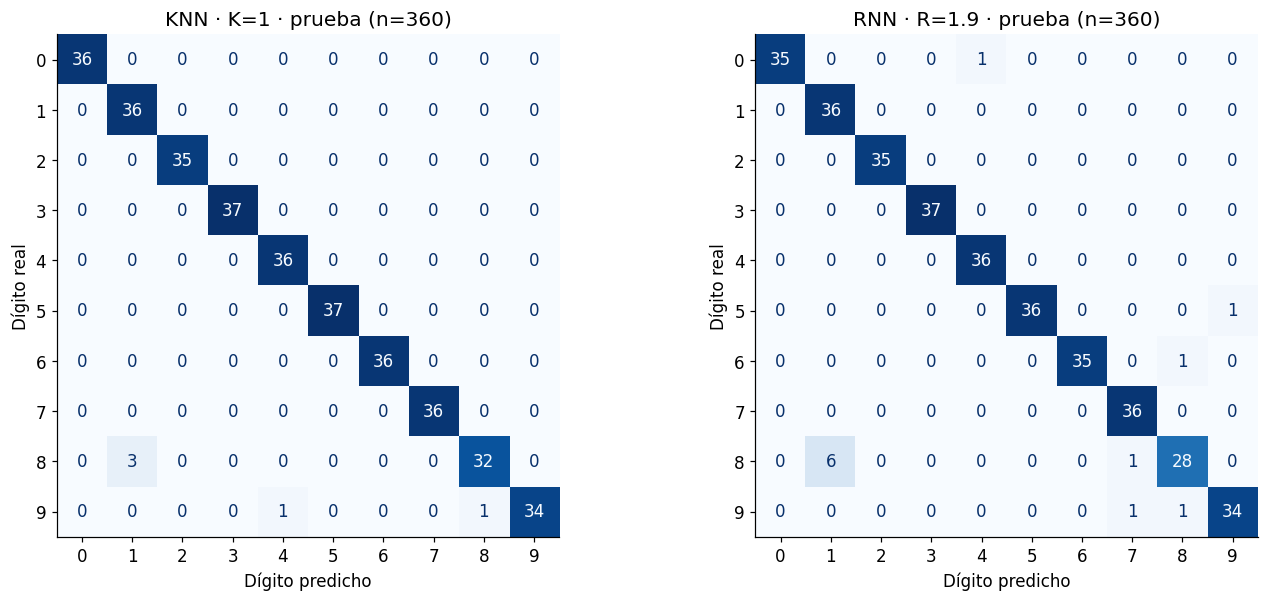

In [15]:
matrices = {n: confusion_matrix(y_test, pred, labels=CLASES)
            for n, pred in predicciones.items()}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
maximo = max(m.max() for m in matrices.values())
for ax, nombre in zip(axes, modelos):
    matriz = matrices[nombre]
    ConfusionMatrixDisplay(matriz, display_labels=CLASES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d',
        im_kw={'vmin': 0, 'vmax': maximo})
    ax.set(title=f'{nombre} · {seleccion_cv.loc[nombre, "Parámetro"]} · prueba (n=360)',
           xlabel='Dígito predicho', ylabel='Dígito real')
    assert matriz.sum() == len(y_test)
    assert np.trace(matriz) == resultado_prueba.loc[nombre, 'Aciertos']
fig.tight_layout()
plt.show()

### 9.2. Desempeño por dígito y confusiones observadas
`support` es el número de imágenes reales de cada clase en prueba. Las tablas muestran los mismos promedios macro usados en la selección, y además los promedios ponderados por el número de imágenes de cada clase. Una clase con pocos errores puede tener métricas sensibles a una o dos imágenes.

In [16]:
for nombre, pred in predicciones.items():
    display(Markdown(f'**Reporte por dígito: {nombre}**'))
    reporte = classification_report(y_test, pred, labels=CLASES, output_dict=True,
                                    zero_division=0)
    # Accuracy global ya aparece en la tabla comparativa; no es una fila por clase.
    reporte.pop('accuracy', None)
    display(pd.DataFrame(reporte).T.rename(columns={'support': 'n_imágenes'}).round(4))
    matriz = matrices[nombre].copy()
    np.fill_diagonal(matriz, 0)
    confusiones = [(int(a), int(b), int(matriz[a, b]))
                  for a, b in zip(*np.where(matriz > 0))]
    confusiones.sort(key=lambda fila: (-fila[2], fila[0], fila[1]))
    print('Principales confusiones (real, predicho, cantidad):', confusiones[:5])

Principales confusiones (real, predicho, cantidad): [(8, 1, 3), (9, 4, 1), (9, 8, 1)]
Principales confusiones (real, predicho, cantidad): [(8, 1, 6), (0, 4, 1), (5, 9, 1), (6, 8, 1), (8, 7, 1)]


**Reporte por dígito: KNN**

,precision,recall,f1-score,n_imágenes
0,1.0000,1.0000,1.0000,36.0
1,0.9231,1.0000,0.9600,36.0
2,1.0000,1.0000,1.0000,35.0
3,1.0000,1.0000,1.0000,37.0
4,0.9730,1.0000,0.9863,36.0
5,1.0000,1.0000,1.0000,37.0
6,1.0000,1.0000,1.0000,36.0
7,1.0000,1.0000,1.0000,36.0
8,0.9697,0.9143,0.9412,35.0
9,1.0000,0.9444,0.9714,36.0


**Reporte por dígito: RNN**

,precision,recall,f1-score,n_imágenes
0,1.0000,0.9722,0.9859,36.0
1,0.8571,1.0000,0.9231,36.0
2,1.0000,1.0000,1.0000,35.0
3,1.0000,1.0000,1.0000,37.0
4,0.9730,1.0000,0.9863,36.0
5,1.0000,0.9730,0.9863,37.0
6,1.0000,0.9722,0.9859,36.0
7,0.9474,1.0000,0.9730,36.0
8,0.9333,0.8000,0.8615,35.0
9,0.9714,0.9444,0.9577,36.0


### 9.3. ¿Cuántas predicciones de RNN utilizaron el respaldo?
Reportamos cobertura en prueba y exactitud solo entre las imágenes cubiertas como un diagnóstico complementario. Esa exactitud condicional **no reemplaza** la exactitud global ni es directamente comparable con un modelo evaluado sobre todas las imágenes. Los casos sin vecinos permanecen en todos los resultados globales.

In [17]:
X_test_normalizado = modelo_rnn.named_steps['escala'].transform(X_test)
with threadpool_limits(limits=1):
    vecinos_prueba = modelo_rnn.named_steps['modelo'].radius_neighbors(
        X_test_normalizado, return_distance=False)
cantidades_prueba = np.array([len(v) for v in vecinos_prueba])
cubiertos = cantidades_prueba > 0
clase_respaldo = int(np.asarray(modelo_rnn.named_steps['modelo'].outlier_label_).ravel()[0])
print(f'Con vecinos: {cubiertos.sum()}/{len(y_test)} ({cubiertos.mean():.2%})')
print(f'Sin vecinos / con respaldo: {(~cubiertos).sum()}/{len(y_test)}')
print('Clase de respaldo del modelo final:', clase_respaldo)
print(f'Vecinos: mínimo={cantidades_prueba.min()}, '
      f'mediana={np.median(cantidades_prueba):.1f}, máximo={cantidades_prueba.max()}')
if cubiertos.any():
    print(f'Exactitud solo en cubiertos: {accuracy_score(y_test[cubiertos], predicciones["RNN"][cubiertos]):.4f}')
if (~cubiertos).any():
    assert np.all(predicciones['RNN'][~cubiertos] == clase_respaldo)
    print(f'Aciertos por respaldo: {np.sum(predicciones["RNN"][~cubiertos] == y_test[~cubiertos])}')

Con vecinos: 360/360 (100.00%)
Sin vecinos / con respaldo: 0/360
Clase de respaldo del modelo final: 1
Vecinos: mínimo=1, mediana=39.0, máximo=132
Exactitud solo en cubiertos: 0.9667


### 9.4. Inspección visual de errores
Se muestran hasta diez imágenes que al menos uno de los modelos clasificó mal, en el orden original de prueba. Cada título incluye la etiqueta real y ambas predicciones. Esto permite inspeccionar casos concretos; no prueba por sí solo la causa del error ni se usa para reajustar los modelos.

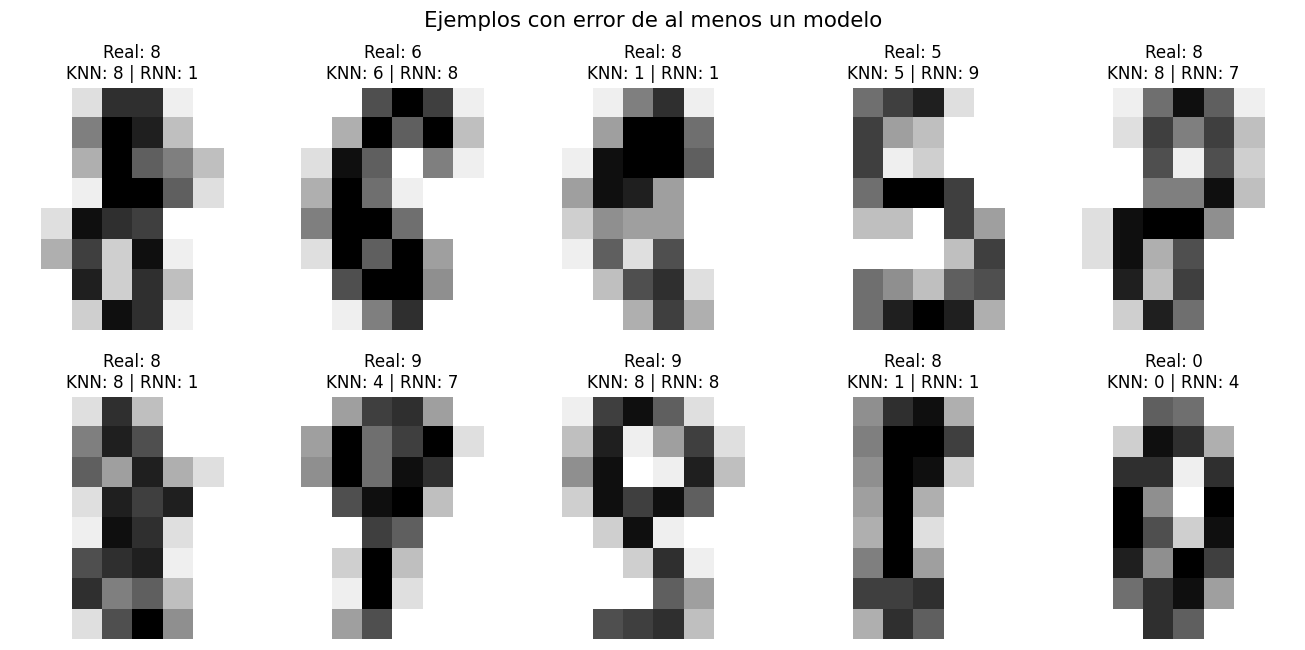

In [18]:
errores_union = np.flatnonzero((predicciones['KNN'] != y_test) | (predicciones['RNN'] != y_test))
if len(errores_union):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6.2))
    for ax in axes.ravel():
        ax.axis('off')
    for ax, i in zip(axes.ravel(), errores_union[:10]):
        ax.imshow(X_test[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=16)
        ax.set_title(f'Real: {y_test[i]}\nKNN: {predicciones["KNN"][i]} | RNN: {predicciones["RNN"][i]}', fontsize=11)
    fig.suptitle('Ejemplos con error de al menos un modelo', fontsize=14)
    fig.tight_layout(h_pad=2.5)
    plt.show()
else:
    print('Ambos modelos clasificaron correctamente todas las imágenes de prueba.')

## 10. Comprobación de una decisión por cálculo directo
Para la primera imagen de prueba calculamos las 1.437 distancias euclidianas mediante NumPy, formamos el vecindario y sumamos votos por clase. La comprobación es independiente del método `predict` de los clasificadores. En una distancia cero solo votan los vecinos de distancia cero; si RNN no tiene vecinos se aplica el respaldo previamente definido.

En caso de empate exacto en la distancia del límite K, distintas implementaciones podrían elegir otro vecino empatado. Se informa si ocurre. Esta celda comprueba un caso, no sustituye la evaluación completa.

In [19]:
def votar_por_distancia(indices, distancias, etiquetas, respaldo=None):
    if len(indices) == 0:
        return respaldo
    dist = distancias[indices]
    pesos = (dist == 0).astype(float) if np.any(dist == 0) else 1.0/dist
    votos = np.bincount(etiquetas[indices], weights=pesos, minlength=10)
    return int(np.argmax(votos))

x_consulta = X_test[0]/16.0
D = np.sqrt(np.sum((X_train/16.0 - x_consulta)**2, axis=1))
orden = np.argsort(D, kind='stable')
vecinos_k = orden[:mejor_k]
vecinos_r = np.flatnonzero(D <= mejor_r)
manual_k = votar_por_distancia(vecinos_k, D, y_train)
manual_r = votar_por_distancia(vecinos_r, D, y_train, clase_respaldo)
empate_limite_k = np.isclose(D[orden[mejor_k-1]], D[orden[mejor_k]], rtol=0, atol=1e-12)
display(pd.DataFrame({
    'Modelo': ['KNN', 'RNN'], 'Vecinos': [len(vecinos_k), len(vecinos_r)],
    'Cálculo directo': [manual_k, manual_r],
    'scikit-learn': [predicciones['KNN'][0], predicciones['RNN'][0]],
    'Dígito real': [y_test[0], y_test[0]]}))
print('Empate en la distancia del límite K:', empate_limite_k)
if not empate_limite_k:
    assert manual_k == predicciones['KNN'][0]
assert manual_r == predicciones['RNN'][0]

Empate en la distancia del límite K: False


,Modelo,Vecinos,Cálculo directo,scikit-learn,Dígito real
0,KNN,1,5,5,5
1,RNN,40,5,5,5


## 11. Respuestas y conclusiones del taller
La siguiente celda redacta las respuestas con los valores realmente calculados. Si se modifican parámetros y se ejecuta todo de nuevo, el texto se actualiza junto con las tablas. No reutilice el conjunto de prueba para afinar K, R o la política de respaldo después de mirar estos resultados.

In [20]:
conclusiones = [
    f'1. **División solicitada:** {len(y_train)} imágenes para entrenamiento y {len(y_test)} para prueba, con estratificación por dígito.',
    f'2. **K-fold:** se utilizaron {len(folds)} folds dentro del entrenamiento. Cada candidato se validó cuatro veces sobre las mismas particiones.',
    f'3. **KNN:** se evaluaron {len(VALORES_K)} valores de K entre {min(VALORES_K)} y {max(VALORES_K)}. Se seleccionó **K={mejor_k}**, con F1 macro medio de validación **{seleccion_cv.loc["KNN", "f1_macro"]:.5f}**.',
    f'4. **RNN:** se evaluaron {len(VALORES_R)} radios entre {min(VALORES_R):g} y {max(VALORES_R):g}, paso 0,1. Se seleccionó **R={mejor_r:g}**, con F1 macro medio de validación **{seleccion_cv.loc["RNN", "f1_macro"]:.5f}**.',
    f'5. **Prueba KNN:** {int(resultado_prueba.loc["KNN", "Aciertos"])} aciertos de {len(y_test)}, exactitud **{resultado_prueba.loc["KNN", "accuracy"]:.2%}** y F1 macro **{resultado_prueba.loc["KNN", "f1_macro"]:.5f}**.',
    f'6. **Prueba RNN:** {int(resultado_prueba.loc["RNN", "Aciertos"])} aciertos de {len(y_test)}, exactitud **{resultado_prueba.loc["RNN", "accuracy"]:.2%}** y F1 macro **{resultado_prueba.loc["RNN", "f1_macro"]:.5f}**. Hubo **{int((~cubiertos).sum())} imágenes sin vecinos**; el respaldo se aplica únicamente en esos casos.',
    f'7. **Comparación:** la familia preferida por validación fue **{modelo_preferido_cv}**. La diferencia observada de exactitud en prueba (KNN menos RNN) fue **{100*(resultado_prueba.loc["KNN", "accuracy"]-resultado_prueba.loc["RNN", "accuracy"]):+.2f} puntos porcentuales**; no constituye por sí sola evidencia de superioridad estadística.'
]
display(Markdown('\n\n'.join(conclusiones)))

1. **División solicitada:** 1437 imágenes para entrenamiento y 360 para prueba, con estratificación por dígito.

2. **K-fold:** se utilizaron 4 folds dentro del entrenamiento. Cada candidato se validó cuatro veces sobre las mismas particiones.

3. **KNN:** se evaluaron 40 valores de K entre 1 y 40. Se seleccionó **K=1**, con F1 macro medio de validación **0.98953**.

4. **RNN:** se evaluaron 36 radios entre 0.5 y 4, paso 0,1. Se seleccionó **R=1.9**, con F1 macro medio de validación **0.98120**.

5. **Prueba KNN:** 355 aciertos de 360, exactitud **98.61%** y F1 macro **0.98589**.

6. **Prueba RNN:** 348 aciertos de 360, exactitud **96.67%** y F1 macro **0.96598**. Hubo **0 imágenes sin vecinos**; el respaldo se aplica únicamente en esos casos.

7. **Comparación:** la familia preferida por validación fue **KNN**. La diferencia observada de exactitud en prueba (KNN menos RNN) fue **+1.94 puntos porcentuales**; no constituye por sí sola evidencia de superioridad estadística.

### Limitaciones y aprendizaje
- Los mejores parámetros dependen de la rejilla, la escala, los votos, las particiones y la métrica elegida. La búsqueda no demuestra un óptimo universal ni continuo para R.
- KNN mantiene constante el número de vecinos; RNN mantiene constante el radio. En RNN, cobertura alta no garantiza clasificación correcta.
- Es una partición aleatoria estratificada del dataset, no una evaluación separada por escritor. Los resultados no garantizan el mismo desempeño con personas nuevas, fotografías o imágenes con otra resolución.
- Los 64 píxeles son sensibles a desplazamiento, orientación y estilo. No se evaluaron otras distancias, ponderaciones ni técnicas de reducción de dimensiones.
- Las medias de validación se calculan dando igual peso a cada fold; la prueba se calcula sobre sus 360 imágenes. La desviación de 4 folds no es un intervalo de confianza.
- Para usar imágenes externas habría que replicar tamaño, rango, orientación y fondo; `load_digits` no equivale a un reconocedor listo para cualquier fotografía.

**Resultado metodológico:** la solución mantiene separados entrenamiento, selección por validación y evaluación final, e informa explícitamente las decisiones de respaldo del clasificador por radio.

## 12. Anexo: tablas completas de la búsqueda
Se muestran todos los candidatos en orden de K y R para verificar que las figuras corresponden al rango completo. Las métricas son medias de validación cruzada, no resultados de prueba. La columna `seleccionado` identifica la elección mediante la regla definida.

In [21]:
with pd.option_context('display.max_rows', 50):
    display(Markdown('**KNN · 40 candidatos**'))
    display(tabla_knn[columnas_knn].round(5))
    display(Markdown('**RNN · 36 candidatos**'))
    display(tabla_rnn[columnas_rnn].round(5))

**KNN · 40 candidatos**

,K,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_std,seleccionado
0,1,0.98956,0.98993,0.98954,0.98953,0.00359,True
1,2,0.98956,0.98993,0.98954,0.98953,0.00359,False
2,3,0.98678,0.98732,0.98674,0.98677,0.00496,False
3,4,0.98469,0.98512,0.98466,0.98464,0.00413,False
4,5,0.98260,0.98309,0.98246,0.98251,0.00449,False
5,6,0.98399,0.98451,0.98389,0.98393,0.00360,False
6,7,0.98260,0.98321,0.98244,0.98250,0.00302,False
7,8,0.98260,0.98319,0.98246,0.98252,0.00454,False
8,9,0.98051,0.98104,0.98031,0.98036,0.00196,False
9,10,0.98121,0.98181,0.98103,0.98107,0.00234,False


**RNN · 36 candidatos**

,R,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_std,cobertura,vecinos_medios,seleccionado
0,0.5,0.10160,0.01016,0.10000,0.01845,0.00024,0.00000,0.00000,False
1,0.6,0.10439,0.11019,0.10278,0.02390,0.00404,0.00418,0.00418,False
2,0.7,0.12526,0.48541,0.12367,0.06314,0.01389,0.03549,0.04454,False
3,0.8,0.18441,0.81108,0.18286,0.16418,0.01410,0.10578,0.15867,False
4,0.9,0.27768,0.88734,0.27630,0.29522,0.02493,0.22062,0.42034,False
5,1.0,0.43356,0.91523,0.43204,0.48475,0.02447,0.39251,0.92416,False
6,1.1,0.57621,0.91936,0.57480,0.63427,0.01759,0.55047,1.74949,False
7,1.2,0.71677,0.92641,0.71566,0.76184,0.01019,0.70216,3.23730,False
8,1.3,0.82673,0.93556,0.82596,0.85241,0.00584,0.82464,5.33620,False
9,1.4,0.89076,0.94650,0.89030,0.90332,0.00889,0.89493,8.18383,False


## 13. Verificación final y entrega
La celda comprueba que se evaluaron ambos rangos completos, que todas las puntuaciones son válidas y que los modelos finales fueron reajustados con las 1.437 imágenes. Las salidas de tablas, figuras y conclusiones deben estar presentes al guardar.

In [22]:
assert len(tabla_knn) == len(VALORES_K)
assert len(tabla_rnn) == len(VALORES_R)
assert busqueda_knn.n_splits_ == busqueda_rnn.n_splits_ == 4
assert tabla_knn['seleccionado'].sum() == tabla_rnn['seleccionado'].sum() == 1
for tabla in [tabla_knn, tabla_rnn, resultado_prueba]:
    valores = tabla[list(NOMBRES_METRICAS)].to_numpy()
    assert np.isfinite(valores).all() and np.all((valores >= 0) & (valores <= 1))
for modelo in modelos.values():
    assert modelo.named_steps['modelo'].n_samples_fit_ == len(y_train)
print('Verificación completada: división 80/20, 4 folds, rangos completos, '
      'selección por CV y evaluación final de los dos modelos.')

Verificación completada: división 80/20, 4 folds, rangos completos, selección por CV y evaluación final de los dos modelos.


### Preparar la entrega indicada en el PDF
1. Completar los nombres de hasta tres integrantes y revisar las explicaciones y resultados.
2. Ejecutar todas las celdas en Colab y guardar el cuaderno con sus salidas.
3. Subir el `.ipynb` a un repositorio propio de GitHub y compartirlo con el profesor `eduardozurek`, según lo solicitado en el enunciado.
4. Enviar la ubicación del repositorio a través de Brightspace. Este archivo no realiza publicaciones, invitaciones ni envíos automáticos.

## 14. Fuentes y adaptación del material de clase
**Enunciado:** `_taller_07_Clasificadores_KNN_RNN.pdf`, página 1, aportado para este taller.

**Repositorio consultado:** [eduardozurek/ia](https://github.com/eduardozurek/ia), versión `9858822357e8`. Se revisaron estos cuadernos:

- [KNN: distancia euclidiana y votos por distancia](https://github.com/eduardozurek/ia/blob/9858822357e88756f228b19025e3206864d4d0c0/_007_aprendizaje_supervisado/_006_01_Clasificador_KNN_K_Nearest_Neighbors_Distancia_Euclidiana.ipynb).
- [RNN: vecinos por radio y manejo de ausencia de vecinos](https://github.com/eduardozurek/ia/blob/9858822357e88756f228b19025e3206864d4d0c0/_007_aprendizaje_supervisado/_006_02_Clasificador_RNN_Vecinos_m%C3%A1s_Cercanos_en_un_Radio_R_Nearest_Neighbors_Distancia_Euclidiana.ipynb).
- [Introducción a GridSearchCV](https://github.com/eduardozurek/ia/blob/9858822357e88756f228b19025e3206864d4d0c0/_007_aprendizaje_supervisado/_006_04_Clasificador_KNN_GridSearch_Cuatro_Categor%C3%ADas_Distancia_Euclidiana.ipynb).
- [Selección multiclase y evaluación separada](https://github.com/eduardozurek/ia/blob/9858822357e88756f228b19025e3206864d4d0c0/_007_aprendizaje_supervisado/_006_04_KNN_GridSearch_Multimetricas_Ponderadas.ipynb).

**Adaptación realizada:** los ejemplos de clase trabajan con datos sintéticos de estatura/peso y distintas configuraciones. Aquí se usa `digits`, división 80/20, cuatro folds, escala fija por 16, métricas macro multiclase y búsquedas restringidas al entrenamiento. Del ejemplo multimétrica se retoma la separación de evaluación; se usa F1 macro como criterio principal, sin adoptar su puntuación compuesta. La implementación es específica para este taller.

**Documentación oficial:**

- [Datos y rango de `load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).
- [`RadiusNeighborsClassifier` y `outlier_label`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html).

La celda de configuración registra las versiones de ejecución. El dataset se carga desde la instalación de scikit-learn, no desde el repositorio del profesor.